# Лабораторна робота №1
## Чисельне моделювання 2D рівняння теплопровідності

**Варіант 5** — тестовий аналітичний розв’язок (Gaussian, фундаментальний розв’язок).

**Виконав:** _(ПІБ, група)_  
**Дата:** _(дата)_

Ноутбук готовий до запуску в **Google Colab** або локально (Python 3, бібліотеки numpy, matplotlib, sympy).

Усі формули та строгий математичний виклад зібрані в **heat_equation_2d_report.tex** (pdflatex). У Markdown нижче — лише текстові пояснення без формул, щоб їх було зручно читати в будь-якому переглядачі.


## 1. Постановка задачі

Потрібно для сталих коефіцієнтів, рівних одиниці, отримати чисельні розв’язки рівняння теплопровідності на площині: похідна за часом дорівнює сумі других похідних за x і за y плю функція f від координат і часу.

Область — прямокутник від нуля до l1 по x і від нуля до l2 по y; час — від нуля до одиниці (у коді кінцевий момент t дорівнює 1).

**Методи:** явна схема (Волков, с. 236); ADI, Пісмен–Рекфорд (Волков, с. 237); двокроковий симетризований LOD (ідеї DS-алгоритмів — Грищенко, Оноцький, ARTICL60.pdf).

Праву частину f відновлюють з точного розв’язку w. Потрібні візуалізація динаміки та графіки абсолютної похибки. Повний запис рівнянь — у файлі heat_equation_2d_report.tex.


## 2. Математична модель

Рівняння у нормованому вигляді з одиничним коефіцієнтом теплопровідності. Початкові значення та значення на межі прямокутника задаються з точного розв’язку для того ж моменту часу (Дирихле).

Сітка рівномірна; після вибору l1 та l2 рівними одиниці кроки по x та y збігаються (позначення h у коді).

Деталі запису — у heat_equation_2d_report.tex.


In [1]:
# Colab: за потреби розкоментуйте
# !pip install -q numpy matplotlib sympy plotly

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display
import sympy as sp
import time
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


In [2]:
# --- Параметри задачі (основна частина) ---
a = 1.0          # коефіцієнт у рівнянні (нормований = 1)
l1 = l2 = 1.0    # розміри прямокутника
T_final = 1.0  # кінець часового інтервалу (0,1] — беремо t=1 як кінець

# Варіант 5: Gaussian / фундаментальний розв’язок
A = 1.0
x0, y0 = 0.5, 0.5
t0 = -0.1        # зсув часу, щоб уникнути сингулярності при t=0

# Сітка (як у плані)
Nx = Ny = 40     # кількість інтервалів => 41 вузол
M = Nx  # для зручності

hx = l1 / Nx
hy = l2 / Ny
assert abs(hx - hy) < 1e-14
h = hx

x = np.linspace(0.0, l1, Nx + 1)
y = np.linspace(0.0, l2, Ny + 1)
X, Y = np.meshgrid(x, y, indexing="ij")

print(f"h = {h:.6g}, Nx=Ny={Nx}, вузлів: {(Nx+1)*(Ny+1)}")


h = 0.025, Nx=Ny=40, вузлів: 1681


## 3. Аналітичний розв’язок (варіант 5)

У методичці для п’ятого варіанту задано гаусоподібний фундаментальний розв’язок: амплітуда обернено пропорційна різниці між часом і зсунутим параметром t0, у показнику експоненти — квадрат відстані від центру джерела, поділений на вираз, лінійний за часом відносно t0, з коефіцієнтом, що містить a.

У коді: A дорівнює одиниці, центр у середині квадрата один на один, t0 від’ємний, щоб уникнути особливості при нульовому часі.

Повна формула — у heat_equation_2d_report.tex, розділ 3.


In [3]:
def w_exact(x, y, t, a=a, A=A, x0=x0, y0=y0, t0=t0):
    """Точний розв’язок (варіант 5). x,y,t можуть бути масивами (broadcast)."""
    dt = t - t0
    # уникнення ділення на нуль у симуляції
    dt = np.maximum(dt, 1e-15)
    r2 = (x - x0) ** 2 + (y - y0) ** 2
    return (A / dt) * np.exp(-r2 / (4.0 * a * dt))


def laplacian_2d(U, h):
    """5-точковий лапласіан на рівномірній сітці; U shape (Nx+1, Ny+1)."""
    L = np.zeros_like(U)
    L[1:-1, 1:-1] = (
        U[2:, 1:-1] - 2 * U[1:-1, 1:-1] + U[:-2, 1:-1]
    ) / h**2 + (
        U[1:-1, 2:] - 2 * U[1:-1, 1:-1] + U[1:-1, :-2]
    ) / h**2
    return L


def dxx(U, h):
    L = np.zeros_like(U)
    L[1:-1, 1:-1] = (U[2:, 1:-1] - 2 * U[1:-1, 1:-1] + U[:-2, 1:-1]) / h**2
    return L


def dyy(U, h):
    L = np.zeros_like(U)
    L[1:-1, 1:-1] = (U[1:-1, 2:] - 2 * U[1:-1, 1:-1] + U[1:-1, :-2]) / h**2
    return L


## 4. Перевірка правої частини f

За визначенням, f — це похідна w за час мінус лапласіан w. Для варіанту 5 при a дорівнює один символьно отримуємо тотожне зникнення f (перевірка в комірці з sympy нижче).


In [4]:
x_s, y_s, t_s = sp.symbols("x y t", real=True)
a_s, A_s = sp.symbols("a A", positive=True)
x0_s, y0_s, t0_s = sp.symbols("x0 y0 t0", real=True)

dt_s = t_s - t0_s
w_s = (A_s / dt_s) * sp.exp(-((x_s - x0_s) ** 2 + (y_s - y0_s) ** 2) / (4 * a_s * dt_s))

f_s = sp.diff(w_s, t_s) - sp.diff(w_s, x_s, 2) - sp.diff(w_s, y_s, 2)
# У рівнянні коефіцієнт дифузії = 1; у формулі варіанту 5 той самий a=1.
f_s_a1 = sp.simplify(f_s.subs(a_s, 1))
print("f = ∂w/∂t - ∂²w/∂x² - ∂²w/∂y²  (після підстановки a=1) =>", f_s_a1)
if f_s_a1 != 0:
    raise AssertionError("Очікувалось f ≡ 0 при a=1.")
print("SymPy: f ≡ 0 для фундаментального Gaussian-розв’язку при a=1.")


f = ∂w/∂t - ∂²w/∂x² - ∂²w/∂y²  (після підстановки a=1) => 0
SymPy: f ≡ 0 для фундаментального Gaussian-розв’язку при a=1.


## 5. Обчислення f у коді

Аналітично для цього тесту f дорівнює нулю. Функція rhs_f повертає нульовий масив для сумісності з усіма схемами.


In [5]:
def rhs_f(x, y, t):
    """Права частина рівняння (для варіанту 5 — тотожно 0)."""
    return np.zeros_like(np.broadcast_arrays(x, y, t)[0], dtype=float)


def rhs_f_on_grid(X, Y, t):
    return rhs_f(X, Y, t)


## 6. Чисельні методи

### 6.1 Явна схема

П’ятиточковий дискретний лапласіан; новий шар дорівнює старому плю крок τ, помножений на суму дискретних других різниць і f. Крок τ обраний меншим за чверть квадрата h (при a дорівнює один у коді — 0.2 від h квадрат).

### 6.2 ADI (Пісмен–Рекфорд)

Два еліптичні підкроки з прогонкою Томаса вздовж x, потім y. У явній частині використовується половина τ, помножена на вже дискретизовані оператори dxx та dyy (вони містять один поділ на h квадрат). Крок по часу для ADI у ноутбуці дорівнює h.

### 6.3 Двокроковий симетризований LOD

Два явні півкроки за x та y, потім два неявні півкроки в зворотному порядку; межі узгоджуються з точним розв’язком, перед неявними кроками оновлюються на кінець повного кроку. Крок τ такий самий, як у явної схеми.

Дискретні формули — у heat_equation_2d_report.tex.


In [6]:
def apply_dirichlet(U, t, X, Y):
    """ГУ Дирихле з точного розв’язку на всіх межах."""
    U[0, :] = w_exact(X[0, :], Y[0, :], t)
    U[-1, :] = w_exact(X[-1, :], Y[-1, :], t)
    U[:, 0] = w_exact(X[:, 0], Y[:, 0], t)
    U[:, -1] = w_exact(X[:, -1], Y[:, -1], t)
    return U


def thomas_tridiag_solve(a, b, c, d):
    """Розв’язати T x = d, T — трикутна: b[i]*x[i] + c[i]*x[i+1] + a[i]*x[i-1] = d[i].
    a[0] і c[-1] не використовуються (нульові зв’язки)."""
    n = len(d)
    cp = np.zeros(n)
    dp = np.zeros(n)
    cp[0] = c[0] / b[0]
    dp[0] = d[0] / b[0]
    for i in range(1, n):
        denom = b[i] - a[i] * cp[i - 1]
        if i < n - 1:
            cp[i] = c[i] / denom
        dp[i] = (d[i] - a[i] * dp[i - 1]) / denom
    x = np.zeros(n)
    x[-1] = dp[-1]
    for i in range(n - 2, -1, -1):
        x[i] = dp[i] - cp[i] * x[i + 1]
    return x


def solve_implicit_x(rhs, tau_half, h, X, Y, t_bc):
    """(I - tau_half * ∂xx) U = rhs; U на межах x та y — з w_exact(t_bc)."""
    r = tau_half / (h * h)
    ni, nj = rhs.shape
    out = np.zeros_like(rhs)
    apply_dirichlet(out, t_bc, X, Y)
    n = ni - 2
    a = np.full(n, -r)
    a[0] = 0.0
    b = np.full(n, 1.0 + 2.0 * r)
    c = np.full(n, -r)
    c[-1] = 0.0
    for j in range(1, nj - 1):
        d_vec = rhs[1:-1, j].copy()
        d_vec[0] += r * out[0, j]
        d_vec[-1] += r * out[-1, j]
        out[1:-1, j] = thomas_tridiag_solve(a, b, c, d_vec)
    apply_dirichlet(out, t_bc, X, Y)
    return out


def solve_implicit_y(rhs, tau_half, h, X, Y, t_bc):
    """(I - tau_half * ∂yy) U = rhs; межі з w_exact(t_bc)."""
    r = tau_half / (h * h)
    ni, nj = rhs.shape
    out = np.zeros_like(rhs)
    apply_dirichlet(out, t_bc, X, Y)
    n = nj - 2
    a = np.full(n, -r)
    a[0] = 0.0
    b = np.full(n, 1.0 + 2.0 * r)
    c = np.full(n, -r)
    c[-1] = 0.0
    for i in range(1, ni - 1):
        d_vec = rhs[i, 1:-1].copy()
        d_vec[0] += r * out[i, 0]
        d_vec[-1] += r * out[i, -1]
        out[i, 1:-1] = thomas_tridiag_solve(a, b, c, d_vec)
    apply_dirichlet(out, t_bc, X, Y)
    return out


def explicit_step(U, tau, h, t_n, X, Y, f_fn):
    """Один крок явної схеми."""
    Un = U.copy()
    F = f_fn(X, Y, t_n)
    Lap = laplacian_2d(Un, h)
    Un[1:-1, 1:-1] += tau * (Lap[1:-1, 1:-1] + F[1:-1, 1:-1])
    apply_dirichlet(Un, t_n + tau, X, Y)
    return Un


def adi_peaceman_rachford_step(U, tau, h, t_n, X, Y, f_fn):
    """Один крок ADI (Peaceman–Rachford). dxx/dyy вже містять 1/h², тож явна частина — (τ/2)·Δ."""
    Un = U.copy()
    Fn = f_fn(X, Y, t_n)
    rhs_star = np.zeros_like(Un)
    rhs_star[1:-1, 1:-1] = (
        Un[1:-1, 1:-1]
        + (tau / 2.0) * dyy(Un, h)[1:-1, 1:-1]
        + (tau / 2.0) * Fn[1:-1, 1:-1]
    )
    t_half = t_n + tau / 2.0
    Wstar = solve_implicit_x(rhs_star, tau / 2.0, h, X, Y, t_half)

    Fnp1 = f_fn(X, Y, t_n + tau)
    rhs_np1 = np.zeros_like(Wstar)
    rhs_np1[1:-1, 1:-1] = (
        Wstar[1:-1, 1:-1]
        + (tau / 2.0) * dxx(Wstar, h)[1:-1, 1:-1]
        + (tau / 2.0) * Fnp1[1:-1, 1:-1]
    )
    Un1 = solve_implicit_y(rhs_np1, tau / 2.0, h, X, Y, t_n + tau)
    return Un1


def symmetric_lod_step(U, tau, h, t_n, X, Y, f_fn):
    """Двокроковий симетризований LOD (явні півкроки x,y + неявні y,x)."""
    Un = U.copy()
    t_mid = t_n + tau / 2.0
    t_np1 = t_n + tau

    Fn = f_fn(X, Y, t_n)
    Fmid = f_fn(X, Y, t_mid)

    # 1) w1 = w^n + (tau/2)*dxx w^n + (tau/4)*f^n
    w1 = Un.copy()
    w1[1:-1, 1:-1] += (tau / 2.0) * dxx(Un, h)[1:-1, 1:-1] + (tau / 4.0) * Fn[1:-1, 1:-1]
    apply_dirichlet(w1, t_mid, X, Y)

    # 2) w2 = w1 + (tau/2)*dyy w1 + (tau/4)*f^{n+1/2}
    w2 = w1.copy()
    w2[1:-1, 1:-1] += (tau / 2.0) * dyy(w1, h)[1:-1, 1:-1] + (tau / 4.0) * Fmid[1:-1, 1:-1]
    apply_dirichlet(w2, t_mid, X, Y)

    # 3–4) Неявні кроки: узгоджуємо межі з t_{n+1} перед еліптичними підзадачами
    w2b = w2.copy()
    apply_dirichlet(w2b, t_np1, X, Y)
    w3 = solve_implicit_y(w2b, tau / 2.0, h, X, Y, t_np1)
    Un1 = solve_implicit_x(w3, tau / 2.0, h, X, Y, t_np1)
    return Un1


def run_simulation(method, tau, T_final, X, Y, h, record_every=None):
    """method: 'explicit' | 'adi' | 'symmetric'"""
    t = 0.0
    U = w_exact(X, Y, t)
    apply_dirichlet(U, t, X, Y)

    history_t = [0.0]
    history_w = [U.copy()]

    f_fn = rhs_f_on_grid
    step_fn = {
        "explicit": explicit_step,
        "adi": adi_peaceman_rachford_step,
        "symmetric": symmetric_lod_step,
    }[method]

    nstep = 0
    t0_clock = time.perf_counter()
    while t < T_final - 1e-15:
        tau_eff = min(tau, T_final - t)
        if method == "explicit" and tau_eff < tau:
            # для останнього дрібного кроку перерахунок не потрібен якщо T кратне tau; інакше
            pass
        U = step_fn(U, tau_eff, h, t, X, Y, f_fn)
        t += tau_eff
        nstep += 1
        if record_every is None or nstep % record_every == 0:
            history_t.append(t)
            history_w.append(U.copy())
    elapsed = time.perf_counter() - t0_clock
    return U, np.array(history_t), history_w, nstep, elapsed


In [7]:
# Кроки часу
tau_explicit = 0.2 * h**2 / a
Nt_expl = int(np.ceil(T_final / tau_explicit))
print(f"Явна схема: tau = {tau_explicit:.3e}, орієнтовно {Nt_expl} кроків до t=1")

# ADI: tau = h (клас PR для параболічних задач дозволяє великий крок)
tau_adi = h
Nt_adi = int(np.ceil(T_final / tau_adi))
# LOD: використовуємо той самий крок, що й для явної схеми (умовна стійкість + узгоджена точність)
tau_sym = tau_explicit
Nt_sym = int(np.ceil(T_final / tau_sym))
print(f"ADI: tau = {tau_adi:.6g}, кроків ~ {Nt_adi}")
print(f"Symmetric LOD: tau = {tau_sym:.3e} (як explicit), кроків ~ {Nt_sym}")

# Запис історії рідше для швидкості анімації
record_every_expl = max(1, Nt_expl // 80)
record_every_fast = max(1, Nt_adi // 80)
record_every_sym = max(1, Nt_sym // 80)  # при τ=τ_expl ~8000 кроків

print("\nЗапуск explicit...")
W_expl, hist_t_e, hist_w_e, n_e, time_e = run_simulation(
    "explicit", tau_explicit, T_final, X, Y, h, record_every=record_every_expl
)
print(f"  кроків: {n_e}, час: {time_e:.3f} s")

print("Запуск ADI...")
W_adi, hist_t_a, hist_w_a, n_a, time_a = run_simulation(
    "adi", tau_adi, T_final, X, Y, h, record_every=record_every_fast
)
print(f"  кроків: {n_a}, час: {time_a:.3f} s")

print("Запуск symmetric LOD...")
W_sym, hist_t_s, hist_w_s, n_s, time_s = run_simulation(
    "symmetric", tau_sym, T_final, X, Y, h, record_every=record_every_sym
)
print(f"  кроків: {n_s}, час: {time_s:.3f} s")


Явна схема: tau = 1.250e-04, орієнтовно 8000 кроків до t=1
ADI: tau = 0.025, кроків ~ 40
Symmetric LOD: tau = 1.250e-04 (як explicit), кроків ~ 8000

Запуск explicit...


  кроків: 8000, час: 0.252 s
Запуск ADI...
  кроків: 40, час: 0.064 s
Запуск symmetric LOD...


  кроків: 8000, час: 12.875 s


## 7. Результати: heatmap, 3D surface, анімація


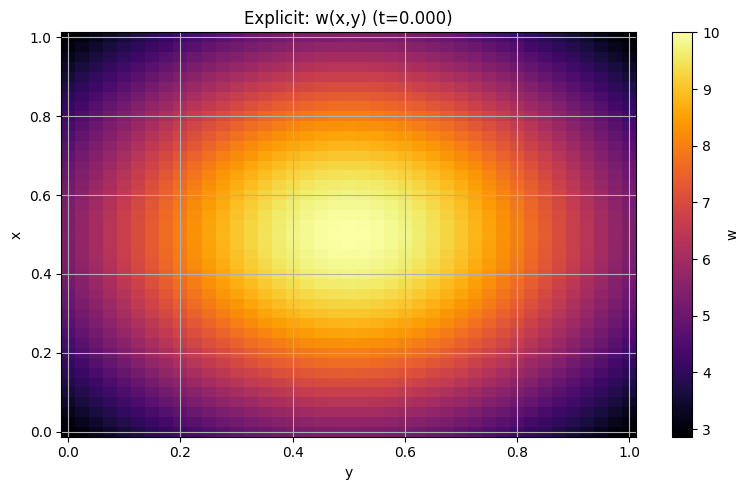

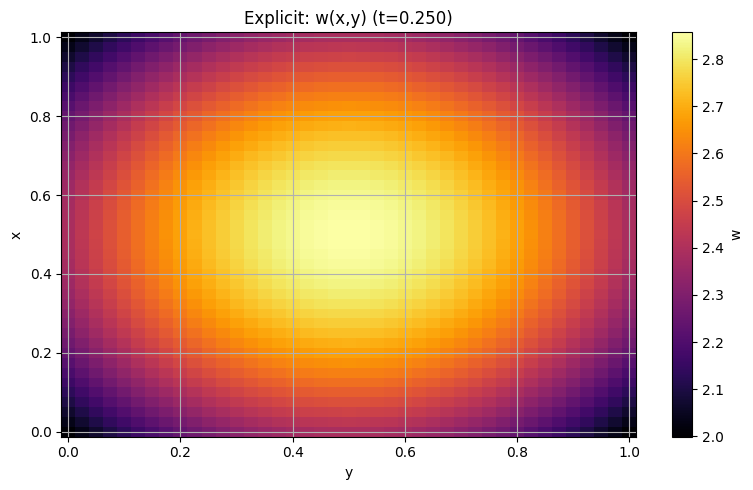

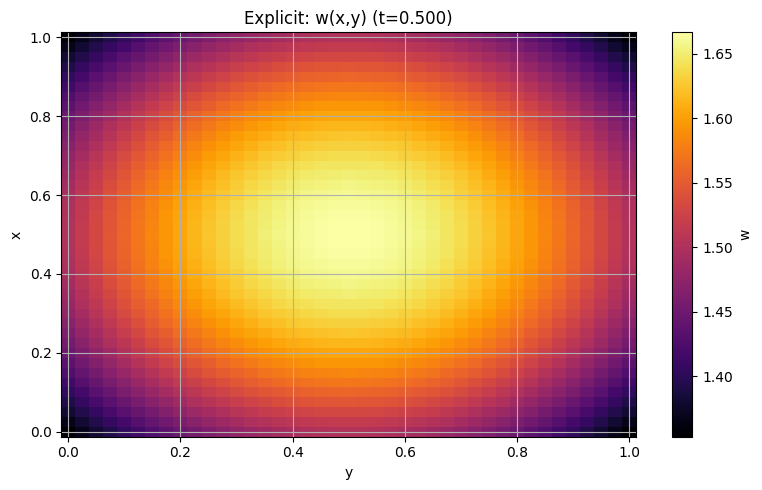

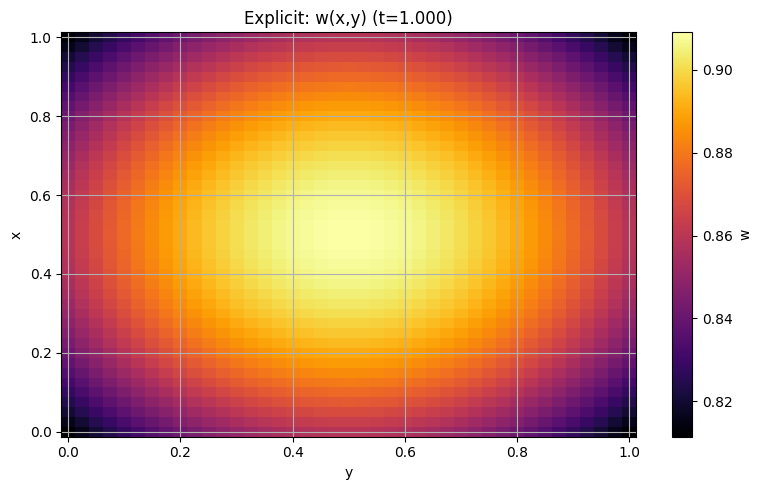

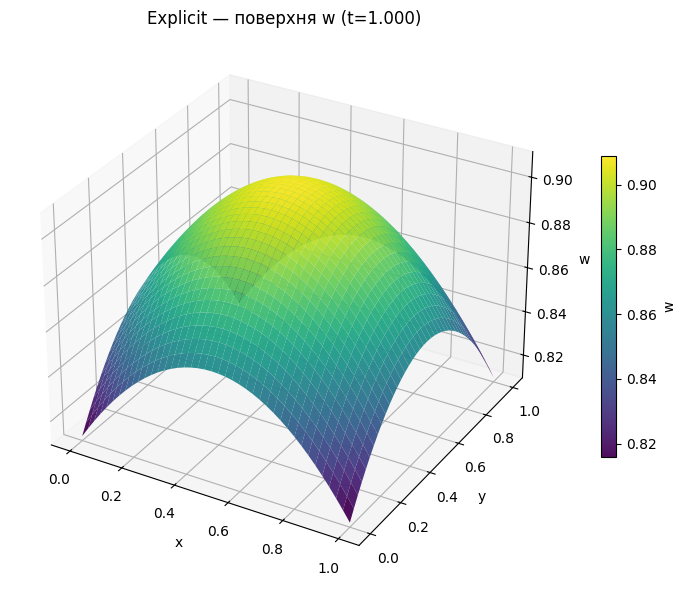

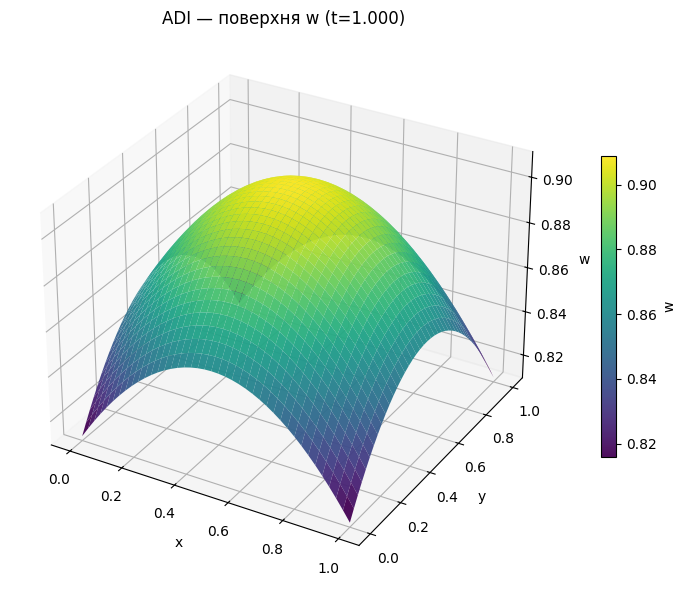

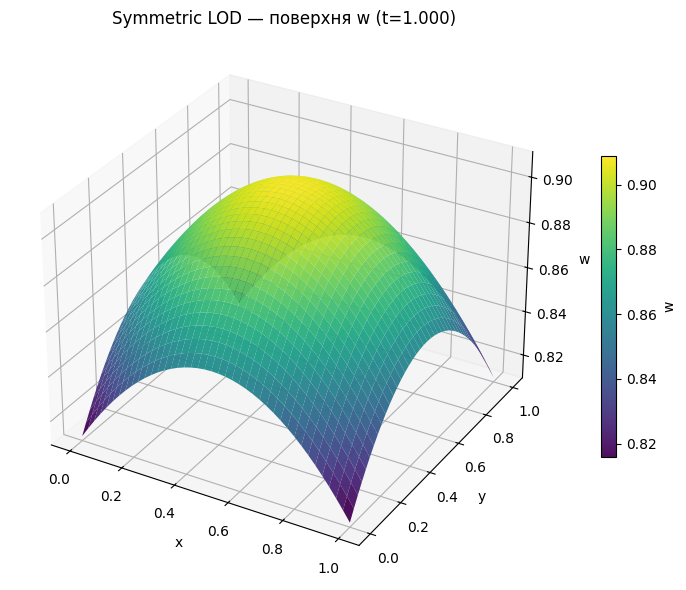

In [8]:
def plot_heatmap(U, title, t_val, vmin=None, vmax=None):
    fig, ax = plt.subplots()
    pcm = ax.pcolormesh(y, x, U.T, shading="auto", cmap="inferno", vmin=vmin, vmax=vmax)
    ax.set_xlabel("y")
    ax.set_ylabel("x")
    ax.set_title(title + f" (t={t_val:.3f})")
    plt.colorbar(pcm, ax=ax, label="w")
    plt.tight_layout()
    plt.show()


def plot_surface_3d(U, title, t_val):
    fig = plt.figure(figsize=(9, 6))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(X, Y, U, cmap="viridis", edgecolor="none", alpha=0.95)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("w")
    ax.set_title(title + f" (t={t_val:.3f})")
    fig.colorbar(surf, shrink=0.55, label="w")
    plt.tight_layout()
    plt.show()


def error_vs_exact(U, t_val):
    We = w_exact(X, Y, t_val)
    return np.abs(U - We)


# Heatmap для кількох моментів часу (explicit як референс-візуалізація)
for tv in [0.0, 0.25, 0.5, 1.0]:
    if tv == 0.0:
        Ue = w_exact(X, Y, 0.0)
    elif tv <= hist_t_e[-1]:
        idx = np.argmin(np.abs(np.array(hist_t_e) - tv))
        Ue = hist_w_e[idx]
    else:
        Ue = W_expl
    plot_heatmap(Ue, "Explicit: w(x,y)", tv)

# 3D surface у фінальний момент
plot_surface_3d(W_expl, "Explicit — поверхня w", T_final)
plot_surface_3d(W_adi, "ADI — поверхня w", T_final)
plot_surface_3d(W_sym, "Symmetric LOD — поверхня w", T_final)


In [9]:
def make_animation(history_t, history_w, title_prefix, frame_step=1):
    fig, ax = plt.subplots()
    vmin = float(np.min(history_w[0]))
    vmax = float(np.max(history_w[0]))
    for W in history_w[:: max(1, len(history_w) // 10)]:
        vmin = min(vmin, float(W.min()))
        vmax = max(vmax, float(W.max()))

    pcm = ax.pcolormesh(y, x, history_w[0].T, shading="auto", cmap="inferno", vmin=vmin, vmax=vmax)
    ax.set_xlabel("y")
    ax.set_ylabel("x")
    ttl = ax.set_title(f"{title_prefix}, t={history_t[0]:.4f}")
    plt.colorbar(pcm, ax=ax, label="w")

    def update(frame):
        k = frame * frame_step
        if k >= len(history_w):
            k = len(history_w) - 1
        pcm.set_array(history_w[k].T.ravel())
        ttl.set_text(f"{title_prefix}, t={history_t[k]:.4f}")
        return (pcm, ttl)

    n_frames = max(1, len(history_w) // frame_step)
    anim = animation.FuncAnimation(
        fig, update, frames=n_frames, interval=120, blit=False
    )
    plt.close(fig)
    return anim


anim_e = make_animation(hist_t_e, hist_w_e, "Explicit", frame_step=max(1, len(hist_w_e) // 60))
try:
    display(HTML(anim_e.to_jshtml()))
except Exception as ex:
    print("to_jshtml failed:", ex)
    print("Спробуйте локально зберегти GIF: pip install pillow")


## 8. Аналіз похибки

Будується модуль різниці між чисельним і точним розв’язком у вузлах; для збереженої історії — максимум за модулем і дискретна евклідова норма з урахуванням площі вузла (підсемплінг кадрів). Деталі визначення норм — у heat_equation_2d_report.tex.


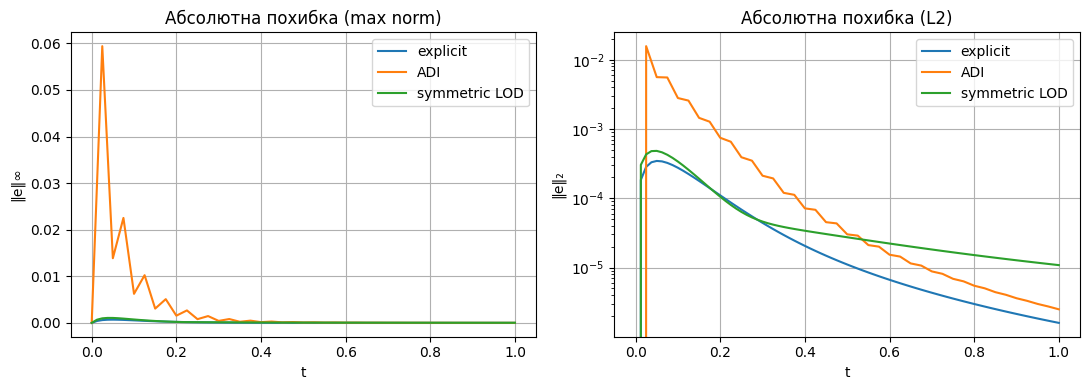

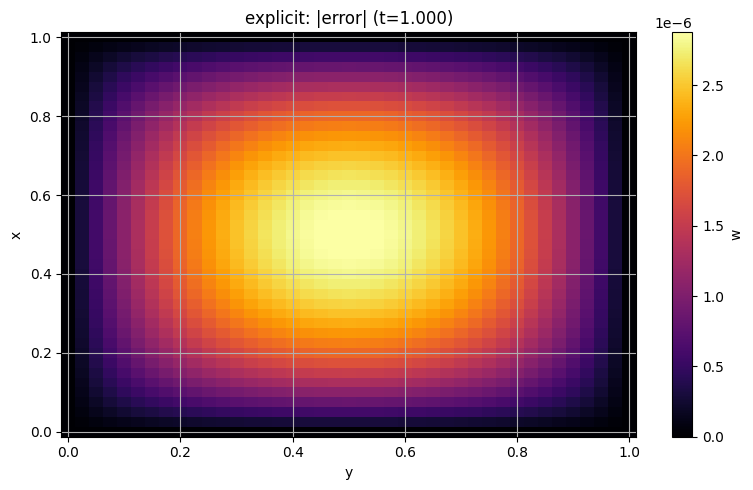

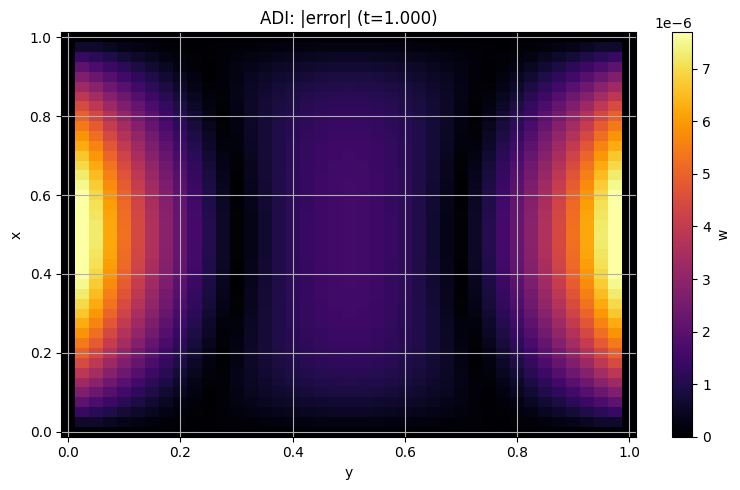

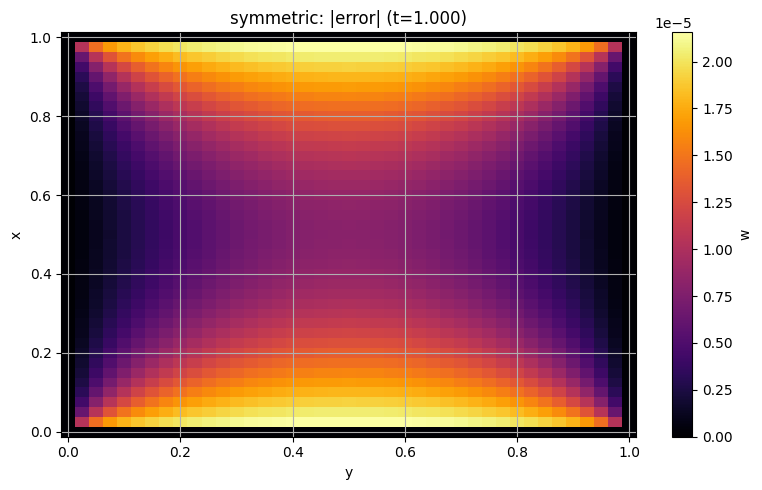

In [10]:
def discrete_l2_norm(E, h):
    """L2 норма на сітці ~ sqrt(h^2 * sum E^2)."""
    return float(np.sqrt(np.sum(E**2) * h * h))


def discrete_linf_norm(E):
    return float(np.max(np.abs(E)))


def error_norms_over_time(history_t, history_w):
    Linf = []
    L2 = []
    for t_k, Wk in zip(history_t, history_w):
        E = np.abs(Wk - w_exact(X, Y, t_k))
        Linf.append(discrete_linf_norm(E))
        L2.append(discrete_l2_norm(E, h))
    return np.array(Linf), np.array(L2)


Le_inf, Le_2 = error_norms_over_time(np.array(hist_t_e), hist_w_e)
La_inf, La_2 = error_norms_over_time(np.array(hist_t_a), hist_w_a)
Ls_inf, Ls_2 = error_norms_over_time(np.array(hist_t_s), hist_w_s)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist_t_e, Le_inf, label="explicit")
ax[0].plot(hist_t_a, La_inf, label="ADI")
ax[0].plot(hist_t_s, Ls_inf, label="symmetric LOD")
ax[0].set_xlabel("t")
ax[0].set_ylabel("‖e‖∞")
ax[0].set_title("Абсолютна похибка (max norm)")
ax[0].legend()

ax[1].semilogy(hist_t_e, Le_2, label="explicit")
ax[1].semilogy(hist_t_a, La_2, label="ADI")
ax[1].semilogy(hist_t_s, Ls_2, label="symmetric LOD")
ax[1].set_xlabel("t")
ax[1].set_ylabel("‖e‖₂")
ax[1].set_title("Абсолютна похибка (L2)")
ax[1].legend()
plt.tight_layout()
plt.show()

# Heatmap похибки у фінальний час
for name, Wf in [("explicit", W_expl), ("ADI", W_adi), ("symmetric", W_sym)]:
    E = error_vs_exact(Wf, T_final)
    plot_heatmap(E, f"{name}: |error|", T_final, vmin=0, vmax=np.percentile(E, 99))


## 9. Порівняння методів

Зведена таблиця та коментарі — у наступній комірці (обчислюються після запуску симуляцій).


In [11]:
def final_errors(W, t_val):
    E = np.abs(W - w_exact(X, Y, t_val))
    return discrete_linf_norm(E), discrete_l2_norm(E, h)


fe_inf, fe_2 = final_errors(W_expl, T_final)
fa_inf, fa_2 = final_errors(W_adi, T_final)
fs_inf, fs_2 = final_errors(W_sym, T_final)

summary_md = f"""
| Метод | Крок tau | Кроків | Час (с) | norm inf при t=1 | norm L2 при t=1 |
|--------|--------|--------|---------|--------------|-------------|
| Явна | {tau_explicit:.3e} | {n_e} | {time_e:.3f} | {fe_inf:.3e} | {fe_2:.3e} |
| ADI | {tau_adi:.6g} | {n_a} | {time_a:.3f} | {fa_inf:.3e} | {fa_2:.3e} |
| Symmetric LOD | {tau_sym:.6g} | {n_s} | {time_s:.3f} | {fs_inf:.3e} | {fs_2:.3e} |
"""
from IPython.display import Markdown
display(Markdown(summary_md))

print('''
Коротка дискусія:
- **Явна** схема умовно стійка; малий τ ⇒ багато кроків, але проста реалізація.
- **ADI (PR)** дозволяє більший τ, зазвичай менше кроків; похибка може бути більшою за явну при великому τ через дискретизацію в часі.
- **Symmetric LOD** — той самий **τ**, що й для явної схеми (узгоджено з умовою стійкості явних підкроків); час більший через дві прогонки на крок.

Для **Gaussian** розв’язку з великими градієнтами біля центру важливі h і τ; зменшення h зменшує просторову дискретизаційну похибку.
''')



| Метод | Крок tau | Кроків | Час (с) | norm inf при t=1 | norm L2 при t=1 |
|--------|--------|--------|---------|--------------|-------------|
| Явна | 1.250e-04 | 8000 | 0.252 | 2.909e-06 | 1.587e-06 |
| ADI | 0.025 | 40 | 0.064 | 8.049e-06 | 2.491e-06 |
| Symmetric LOD | 0.000125 | 8000 | 12.875 | 2.171e-05 | 1.083e-05 |



Коротка дискусія:
- **Явна** схема умовно стійка; малий τ ⇒ багато кроків, але проста реалізація.
- **ADI (PR)** дозволяє більший τ, зазвичай менше кроків; похибка може бути більшою за явну при великому τ через дискретизацію в часі.
- **Symmetric LOD** — той самий **τ**, що й для явної схеми (узгоджено з умовою стійкості явних підкроків); час більший через дві прогонки на крок.

Для **Gaussian** розв’язку з великими градієнтами біля центру важливі h і τ; зменшення h зменшує просторову дискретизаційну похибку.



## 10. Висновки (основна задача)

1. Реалізовано три методи для двовимірного рівняння теплопровідності з тестовим розв’язком п’ятого варіанту та узгодженими початковою і граничними умовами.
2. Символьно підтверджено, що відновлена права частина f зникає тотожно при a дорівнює один; чисельні схеми з узгодженим нульовим джерелом.
3. Побудовано heatmap, тривимірні поверхні та анімацію; порівняно методи за нормами похибки та часом рахунку.

---

# Додаткове дослідження: фізична інтерпретація та розширення моделі

Рівняння та формули тривимірного блоку — у heat_equation_2d_report.tex.


### Д.1 Фізична інтерпретація: мідна пластина та локальне джерело

Для міді наведено порядок величин теплопровідності, щільності та питомої теплоємності; з них виходить коефіцієнт температуропровідності порядку десяти в мінус четвертому степені квадратних метрів на секунду.

Перехід до безрозмірних координат і часу зводить запис до вигляду лабораторної з одиничним коефіцієнтом у головній частині рівняння.

Гаусоподібний розв’язок інтерпретується як відповідь на ідеалізоване локальне імпульсне нагрівання; з часом профіль розмивається по пластині.

Числові константи та безрозмірний перехід — у heat_equation_2d_report.tex.


### Д.2 Експерименти з граничними умовами

Охолодження: температура на всьому контурі фіксується нулем при гаусоподібному початку всередині.

Ізоляція: на межі задається нульовий нормальний потік (Нейман); у коді для лапласіана використовуються віддзеркалені привидні вузли.

Демонстрація — явною схемою на тій самій сітці.


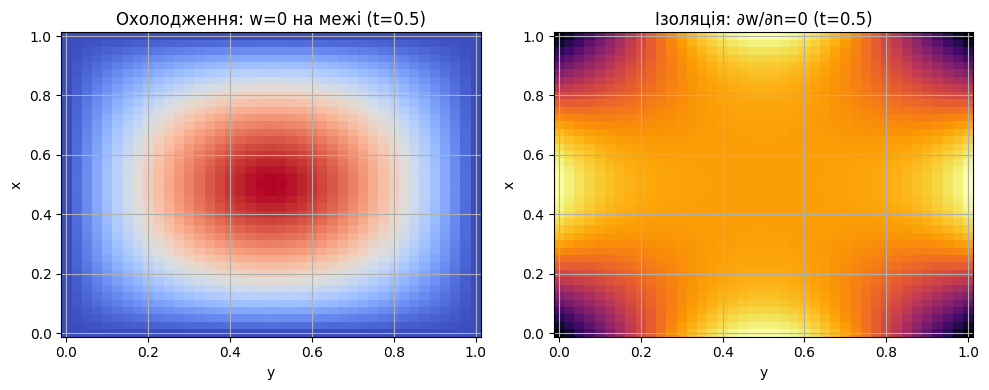

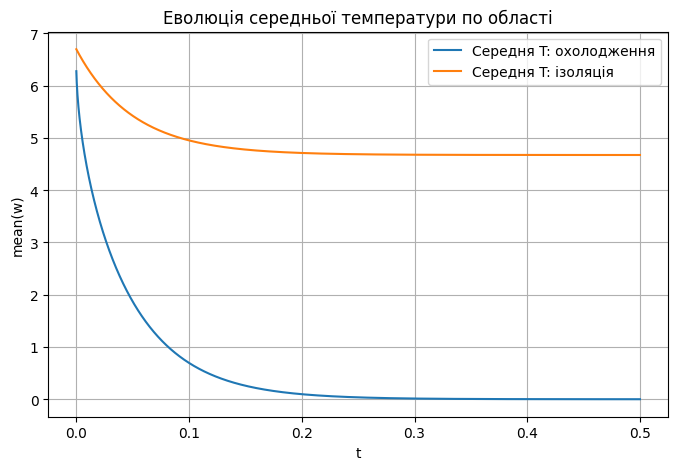

In [12]:
def laplacian_2d_neumann(U, h):
    """Лапласіан з однорідними Neumann ∂u/∂n=0 (ghost: u_{-1}=u_{+1})."""
    nx, ny = U.shape
    Gi = np.empty((nx + 2, ny + 2))
    Gi[1:-1, 1:-1] = U
    Gi[0, 1:-1] = Gi[2, 1:-1]
    Gi[-1, 1:-1] = Gi[-3, 1:-1]
    Gi[1:-1, 0] = Gi[1:-1, 2]
    Gi[1:-1, -1] = Gi[1:-1, -3]
    Gi[0, 0] = Gi[2, 2]
    Gi[0, -1] = Gi[2, -3]
    Gi[-1, 0] = Gi[-3, 2]
    Gi[-1, -1] = Gi[-3, -3]
    Lap = np.zeros_like(U)
    # внутрішні вузли (i,j) = (1..nx-2, 1..ny-2) — 5-точковий стенсіл
    Lap[1:-1, 1:-1] = (
        (Gi[3 : nx + 1, 2:ny] - 2 * Gi[2:nx, 2:ny] + Gi[1 : nx - 1, 2:ny])
        + (Gi[2:nx, 3 : ny + 1] - 2 * Gi[2:nx, 2:ny] + Gi[2:nx, 1 : ny - 1])
    ) / (h * h)
    return Lap


def explicit_step_neumann(U, tau, h, t_n, X, Y, f_fn):
    """Явний крок з однорідними Neumann на межі (нульовий потік тепла)."""
    Un = U.copy()
    Lap = laplacian_2d_neumann(Un, h)
    F = f_fn(X, Y, t_n)
    Un[1:-1, 1:-1] += tau * (Lap[1:-1, 1:-1] + F[1:-1, 1:-1])
    return Un


def run_explicit_bc(bc_kind, T_end, tau):
    t = 0.0
    U = w_exact(X, Y, 0.0)
    if bc_kind == "dirichlet_zero":
        U[0, :] = U[-1, :] = U[:, 0] = U[:, -1] = 0.0
    means = [float(np.mean(U))]
    ts = [0.0]
    while t < T_end - 1e-15:
        dt = min(tau, T_end - t)
        if bc_kind == "dirichlet_zero":
            U = explicit_step(U, dt, h, t, X, Y, rhs_f_on_grid)
            U[0, :] = U[-1, :] = U[:, 0] = U[:, -1] = 0.0
        else:
            U = explicit_step_neumann(U, dt, h, t, X, Y, rhs_f_on_grid)
        t += dt
        ts.append(t)
        means.append(float(np.mean(U)))
    return U, ts, means


tau_demo = tau_explicit
U_cold, ts_c, mean_cold = run_explicit_bc("dirichlet_zero", 0.5, tau_demo)
U_iso, ts_i, mean_iso = run_explicit_bc("neumann", 0.5, tau_demo)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].pcolormesh(y, x, U_cold.T, shading="auto", cmap="coolwarm")
ax[0].set_title("Охолодження: w=0 на межі (t=0.5)")
ax[0].set_xlabel("y")
ax[0].set_ylabel("x")

ax[1].pcolormesh(y, x, U_iso.T, shading="auto", cmap="inferno")
ax[1].set_title("Ізоляція: ∂w/∂n=0 (t=0.5)")
ax[1].set_xlabel("y")
ax[1].set_ylabel("x")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(ts_c, mean_cold, label="Середня T: охолодження")
plt.plot(ts_i, mean_iso, label="Середня T: ізоляція")
plt.xlabel("t")
plt.ylabel("mean(w)")
plt.legend()
plt.title("Еволюція середньої температури по області")
plt.show()


### Д.3 Розширення до 3D: тонка пластина з нагрівачем позаду

Геометрія: тонка пластина зі співвідношенням сторін ширина:висота:товщина = 1 : 1 : 1/50 (наприклад, мідна пластинка один метр на один метр, товщина два сантиметри).

Фізична постановка:

- нагрівальний елемент квадратний і рівномірний, розміщений позаду у площині z = 0, з відступом 1 см від країв;
- задня сторона (z = 0) повністю ізольована: нульовий тепловий потік (Нейман);
- бічні грані (по x і по y) також повністю ізольовані;
- передня сторона (z = товщина) — контакт із повітрям кімнатної температури: **конвекція Ньютона** (умова Робена), а не Дирихле. У змінній «надлишок відносно кімнати» $w=0$ — це саме температура повітря; поверхня пластини може бути **теплішою за повітря** ($w>0$), бо тепло йде зсередини;
- початкова температура дорівнює кімнатній (надлишок $w=0$ скрізь).

У коді — явна семиточкова схема з ghost-вузлами, анізотропна сітка. Повний запис — у heat_equation_2d_report.tex.


In [13]:
# --- 3D: тонка пластина з нагрівачем позаду ---
Lx3 = 1.0
Ly3 = 1.0
Lz3 = 1.0 / 50.0

Nx3 = 30
Ny3 = 30
Nz3 = 6
hx3 = Lx3 / Nx3
hy3 = Ly3 / Ny3
hz3 = Lz3 / Nz3

x3 = np.linspace(0.0, Lx3, Nx3 + 1)
y3 = np.linspace(0.0, Ly3, Ny3 + 1)
z3 = np.linspace(0.0, Lz3, Nz3 + 1)
X3, Y3, Z3 = np.meshgrid(x3, y3, z3, indexing="ij")

# Нагрівач: квадратний рівномірний на задній стороні z=0
# Відступ 1 см від країв при пластині 30x30 см => частка 1/30 від розміру по x,y
margin_frac = 1.0 / 30.0
Q_src = 12000.0  # інтенсивність нагрівача (безрозмірно)
heater_thickness = Lz3 / 6.0  # невелика товщина джерела біля z=0
mask_xy = (
    (X3 >= margin_frac * Lx3) & (X3 <= (1.0 - margin_frac) * Lx3) &
    (Y3 >= margin_frac * Ly3) & (Y3 <= (1.0 - margin_frac) * Ly3)
)
mask_z = Z3 <= heater_thickness
F3 = Q_src * (mask_xy & mask_z).astype(float)


# Число Біо для переду: h*ell3/k (безрозмірно); більше — сильніша конвекція (поверхня ближче до Т_повітря)
BIOT_FRONT = 0.35


def laplacian_3d_mixed_bc(U, hx, hy, hz, Lz_plate, biot_front):
    # ghost: Нейман на z=0, x, y; на z=Lz — Робен ∂w/∂z + (biot/Lz) w = 0 (w — надлишок відносно кімнати).
    nx, ny, nz_ = U.shape
    G = np.empty((nx + 2, ny + 2, nz_ + 2))
    G[1:-1, 1:-1, 1:-1] = U
    G[0, 1:-1, 1:-1] = G[2, 1:-1, 1:-1]
    G[-1, 1:-1, 1:-1] = G[-3, 1:-1, 1:-1]
    G[1:-1, 0, 1:-1] = G[1:-1, 2, 1:-1]
    G[1:-1, -1, 1:-1] = G[1:-1, -3, 1:-1]
    G[1:-1, 1:-1, 0] = G[1:-1, 1:-1, 2]
    G[1:-1, 1:-1, -1] = G[1:-1, 1:-1, -3] - 2.0 * hz * (biot_front / Lz_plate) * G[1:-1, 1:-1, -2]
    L = (
        (G[2:, 1:-1, 1:-1] - 2 * G[1:-1, 1:-1, 1:-1] + G[:-2, 1:-1, 1:-1]) / (hx * hx)
        + (G[1:-1, 2:, 1:-1] - 2 * G[1:-1, 1:-1, 1:-1] + G[1:-1, :-2, 1:-1]) / (hy * hy)
        + (G[1:-1, 1:-1, 2:] - 2 * G[1:-1, 1:-1, 1:-1] + G[1:-1, 1:-1, :-2]) / (hz * hz)
    )
    return L


tau3_max = 1.0 / (2.0 * a * (1.0 / hx3 ** 2 + 1.0 / hy3 ** 2 + 1.0 / hz3 ** 2))
tau3 = 0.4 * tau3_max
T3 = 0.001
nsteps3 = int(np.ceil(T3 / tau3))
print(f"3D: tau_max={tau3_max:.3e}, tau={tau3:.3e}, steps={nsteps3}")

U3 = np.zeros_like(X3)  # надлишок температури відносно кімнати (Т_кімн = 0 у цій шкалі)

snap_frames = [0, nsteps3 // 4, nsteps3 // 2, 3 * nsteps3 // 4, nsteps3]
snap_times = [0.0]
snaps = [U3.copy()]

t3 = 0.0
for step in range(1, nsteps3 + 1):
    dt = min(tau3, T3 - t3)
    Lap = laplacian_3d_mixed_bc(U3, hx3, hy3, hz3, Lz3, BIOT_FRONT)
    U3 = U3 + dt * (Lap + F3)
    t3 += dt
    if step in snap_frames:
        snaps.append(U3.copy())
        snap_times.append(t3)

print(
    f"3D: max w = {U3.max():.4e}, max w на передній грані z=Lz = {U3[:, :, -1].max():.4e} "
    f"(>0 означає тепліше за повітря)"
)


3D: tau_max=5.447e-06, tau=2.179e-06, steps=459
3D: max w = 2.5550e+00, max w на передній грані z=Lz = 1.7843e+00 (>0 означає тепліше за повітря)


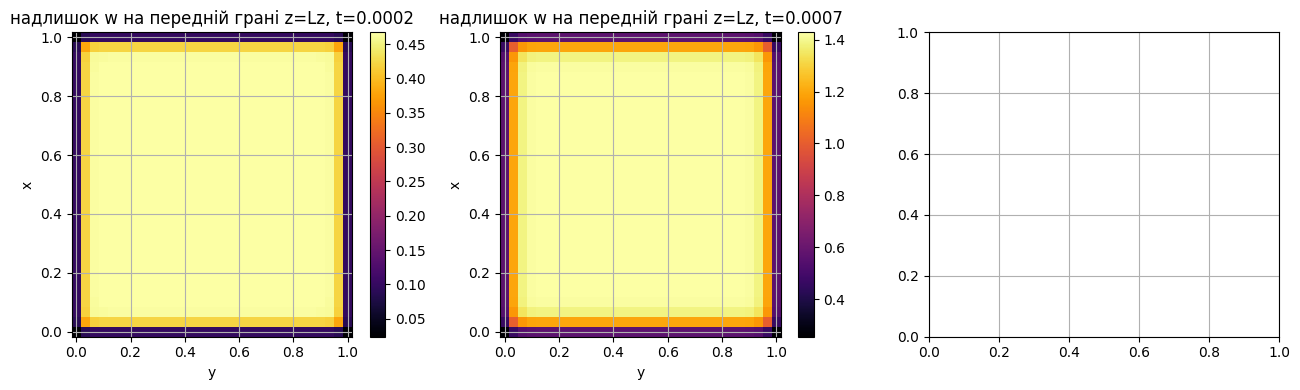

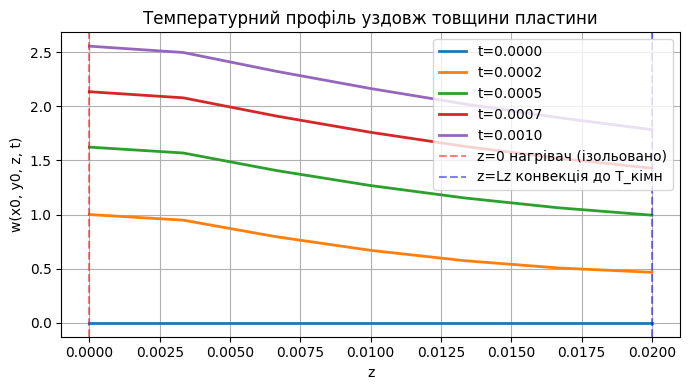

In [14]:
# Статичні matplotlib-візуалізації (heatmap на передній грані, розріз, профіль по z)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax_i, tv, Uk in zip(axes, snap_times[1::2][:3], snaps[1::2][:3]):
    pcm = ax_i.pcolormesh(y3, x3, Uk[:, :, -1].T, shading="auto", cmap="inferno")
    ax_i.set_xlabel("y")
    ax_i.set_ylabel("x")
    ax_i.set_title(f"надлишок w на передній грані z=Lz, t={tv:.4f}")
    fig.colorbar(pcm, ax=ax_i)
fig.tight_layout()
plt.show()

# Профіль уздовж z через центр нагрівача
fig, ax = plt.subplots(figsize=(7, 4))
i0 = Nx3 // 2
j0 = Ny3 // 2
for Uk, tv in zip(snaps, snap_times):
    ax.plot(z3, Uk[i0, j0, :], label=f"t={tv:.4f}", lw=2)
ax.axvline(0, color="red", ls="--", alpha=0.5, label="z=0 нагрівач (ізольовано)")
ax.axvline(Lz3, color="blue", ls="--", alpha=0.5, label="z=Lz конвекція до Т_кімн")
ax.set_xlabel("z")
ax.set_ylabel("w(x0, y0, z, t)")
ax.set_title("Температурний профіль уздовж товщини пластини")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


#### Числове керування без слайдерів: і час, і потужність

Для керування задаються **числами**:

- `Q_ctrl` — потужність квадратного нагрівача на задній стороні;
- `T_ctrl` — кінець інтервалу часу.

Нижче:
1) прямий розрахунок для заданих `Q_ctrl`, `T_ctrl`;
2) автопідбір пари `(Q, t)` під цільову температуру на передній грані.


Пряме керування (задано чисельно):
                 Q: 1.200000e+03
                 T: 1.000000e-02
        front_mean: 3.125220e-01
         front_std: 4.778576e-02
         front_min: 1.388919e-01
         front_max: 3.427134e-01
  uniformity_index: 8.470963e-01


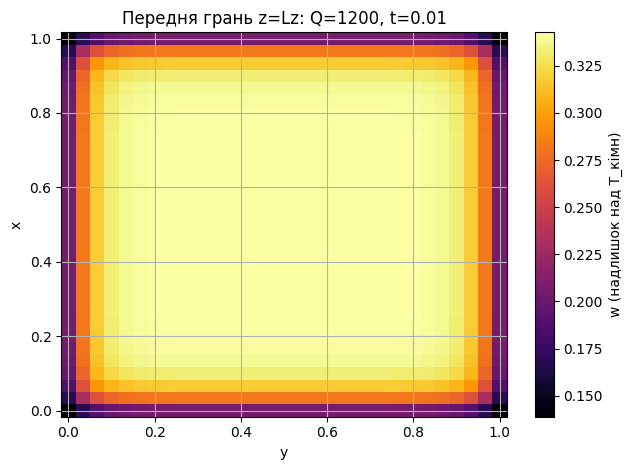


Автопідбір (по сітці Q x T):
  target front_mean = 2.200000e-01
  target uniformity = 8.500000e-01
  best score        = 3.421897e-04
  best           Q = 9.000000e+02
  best           T = 4.000000e-03
  best  front_mean = 2.235618e-01
  best   front_std = 3.523466e-02
  best   front_min = 9.541614e-02
  best   front_max = 2.453678e-01
  best uniformity_index = 8.423941e-01


In [15]:
# --- Числове керування Q і часу (без слайдерів) ---
def run_3d_case(Q_case, T_case, biot_front=BIOT_FRONT):
    F_case = Q_case * (mask_xy & mask_z).astype(float)
    U_case = np.zeros_like(X3)
    t_case = 0.0
    while t_case < T_case - 1e-15:
        dt = min(tau3, T_case - t_case)
        Lap = laplacian_3d_mixed_bc(U_case, hx3, hy3, hz3, Lz3, biot_front)
        U_case = U_case + dt * (Lap + F_case)
        t_case += dt

    front = U_case[:, :, -1]
    m_front = float(np.mean(front))
    s_front = float(np.std(front))
    mx_front = float(np.max(front))
    mn_front = float(np.min(front))
    uniformity = 1.0 - (s_front / (abs(m_front) + 1e-12))  # 1 = ідеально рівномірно
    return U_case, {
        "Q": float(Q_case),
        "T": float(T_case),
        "front_mean": m_front,
        "front_std": s_front,
        "front_min": mn_front,
        "front_max": mx_front,
        "uniformity_index": float(uniformity),
    }


# Режим 1: пряме керування
Q_ctrl = 1200.0
T_ctrl = 0.01

U_ctrl, stats_ctrl = run_3d_case(Q_ctrl, T_ctrl, biot_front=BIOT_FRONT)
print("Пряме керування (задано чисельно):")
for k, v in stats_ctrl.items():
    print(f"  {k:>16s}: {v:.6e}" if isinstance(v, float) else f"  {k}: {v}")

fig, ax = plt.subplots(figsize=(6.5, 4.8))
pcm = ax.pcolormesh(y3, x3, U_ctrl[:, :, -1].T, shading="auto", cmap="inferno")
ax.set_xlabel("y")
ax.set_ylabel("x")
ax.set_title(f"Передня грань z=Lz: Q={Q_ctrl:.0f}, t={T_ctrl}")
fig.colorbar(pcm, ax=ax, label="w (надлишок над T_кімн)")
fig.tight_layout()
plt.show()


# Режим 2: автопідбір Q і T під ціль
target_front_mean = 0.22   # бажане середнє на передній грані
target_uniformity = 0.85   # бажана рівномірність (ближче до 1 — краще)

Q_grid = np.linspace(600.0, 3000.0, 9)
T_grid = np.linspace(0.004, 0.03, 8)

best = None
best_score = 1e99
for Q_try in Q_grid:
    for T_try in T_grid:
        _, st = run_3d_case(Q_try, T_try, biot_front=BIOT_FRONT)
        score = (
            ((st["front_mean"] - target_front_mean) / (target_front_mean + 1e-12)) ** 2
            + ((st["uniformity_index"] - target_uniformity) / (target_uniformity + 1e-12)) ** 2
        )
        if score < best_score:
            best_score = score
            best = st

print("\nАвтопідбір (по сітці Q x T):")
print(f"  target front_mean = {target_front_mean:.6e}")
print(f"  target uniformity = {target_uniformity:.6e}")
print(f"  best score        = {best_score:.6e}")
for k in ["Q", "T", "front_mean", "front_std", "front_min", "front_max", "uniformity_index"]:
    print(f"  best {k:>11s} = {best[k]:.6e}")


#### Інтерактивний Plotly: два слайдери `t` та `w` (потужність)

Повернутий інтерактивний режим: у цій комірці є два слайдери:

- `t` — час;
- `w` — потужність нагрівача (той самий параметр, що `Q` у коді).


In [16]:
# Plotly + ipywidgets: одночасне керування часом і потужністю
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

Z_SCALE = 15.0
z_vis = z3 * Z_SCALE
Lz_vis = Lz3 * Z_SCALE


def make_surfaces(U, vmax):
    kwargs = dict(
        colorscale="Turbo", cmin=0.0, cmax=vmax, showscale=False,
        lighting=dict(ambient=1.0, diffuse=0.35, specular=0.05),
    )
    traces = []
    Z0 = np.zeros_like(X3[:, :, 0])
    traces.append(go.Surface(x=X3[:, :, 0], y=Y3[:, :, 0], z=Z0,
                             surfacecolor=U[:, :, 0], **kwargs, name="Задня z=0"))
    Zf = np.full_like(X3[:, :, 0], Lz_vis)
    traces.append(go.Surface(x=X3[:, :, 0], y=Y3[:, :, 0], z=Zf,
                             surfacecolor=U[:, :, -1], **kwargs, name="Передня z=Lz"))
    Yl, Zl = np.meshgrid(y3, z_vis, indexing="ij")
    traces.append(go.Surface(x=np.zeros_like(Yl), y=Yl, z=Zl,
                             surfacecolor=U[0, :, :], **kwargs, name="x=0"))
    traces.append(go.Surface(x=np.full_like(Yl, Lx3), y=Yl, z=Zl,
                             surfacecolor=U[-1, :, :], **kwargs, name="x=Lx"))
    Xbw, Zbw = np.meshgrid(x3, z_vis, indexing="ij")
    traces.append(go.Surface(x=Xbw, y=np.zeros_like(Xbw), z=Zbw,
                             surfacecolor=U[:, 0, :], **kwargs, name="y=0"))
    traces.append(go.Surface(x=Xbw, y=np.full_like(Xbw, Ly3), z=Zbw,
                             surfacecolor=U[:, -1, :], **kwargs, name="y=Ly"))
    return traces


# Базові дані по часу беремо зі snaps (це розв'язок для Q_src)
U_time = list(snaps)
t_time = list(snap_times)
vmax_global = float(max(u.max() for u in U_time) * (3000.0 / Q_src) * 1.02)

q_slider = widgets.FloatSlider(
    value=float(Q_src), min=300.0, max=3000.0, step=100.0, description="w(Q):",
    continuous_update=False, readout_format=".0f",
)
t_slider = widgets.FloatSlider(
    value=float(t_time[-1]), min=float(t_time[0]), max=float(t_time[-1]),
    step=float((t_time[-1] - t_time[0]) / max(1, len(t_time) - 1)),
    description="t:", continuous_update=False, readout_format=".4f",
)


def pick_time_snapshot(t_val):
    idx = int(np.argmin(np.abs(np.array(t_time) - t_val)))
    return idx, U_time[idx], t_time[idx]


def redraw(q_val, t_val):
    idx, U_base, t_snap = pick_time_snapshot(t_val)
    U = U_base * (q_val / Q_src)  # лінійне масштабування по потужності джерела
    fig = go.Figure(data=make_surfaces(U, vmax_global))
    fig.add_trace(go.Surface(
        x=[[0]], y=[[0]], z=[[0]], surfacecolor=[[0]], colorscale="Turbo",
        cmin=0.0, cmax=vmax_global, showscale=True,
        colorbar=dict(title="w", thickness=18, len=0.7, x=1.02),
        opacity=0.0, showlegend=False, name="cb"
    ))
    fig.update_layout(
        title=f"3D: square_back_heater (відступ 1 см від країв) | t≈{t_snap:.4f}, w(Q)={q_val:.0f}",
        scene=dict(
            xaxis=dict(title="x", range=[0, Lx3]),
            yaxis=dict(title="y", range=[0, Ly3]),
            zaxis=dict(title=f"z (×{Z_SCALE:.0f})", range=[0, Lz_vis]),
            aspectratio=dict(x=1, y=1, z=0.35),
            camera=dict(eye=dict(x=1.35, y=-0.55, z=0.45), center=dict(x=0.45, y=0.45, z=0.12)),
        ),
        width=950, height=620, margin=dict(l=10, r=10, t=60, b=10),
    )
    fig.show()


ui = widgets.HBox([t_slider, q_slider])
out = widgets.interactive_output(redraw, {"q_val": q_slider, "t_val": t_slider})
display(ui, out)


Output()

### Д.4 Підсумок: 2D проти 3D

- Для тонкої пластини характерний дифузійний час уздовж товщини значно менший за час уздовж площини, тому профіль по товщині встановлюється швидко; у квазістаціонарі він близький до лінійного (рівняння Фур’є для стаціонарного одновимірного випадку).
- Обчислювальна вартість явної схеми у тривимірному випадку зростає як добуток кількості вузлів по трьох осях; анізотропна сітка посилює обмеження на крок за часом (CFL тут визначається найдрібнішим кроком).
- Неявні схеми (ADI, двокроковий симетризований) особливо вигідні для тонких пластин, де анізотропія робить CFL-обмеження на явну схему жорстким.

---

Кінець ноутбука. Повні формули та теоретичне обґрунтування — у heat_equation_2d_report.tex.
